# A/B Test Analysis — Marketing Experiment

This notebook analyses the results of a marketing email A/B test:

- **Control**: existing email design
- **Treatment**: new email design

We examine conversion rate (did the user make a purchase?) and revenue,
run a power analysis, and apply statistical significance tests to decide
whether the treatment's effect is real or likely due to chance.


## 1. Setup

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"

sys.path.insert(0, str(SRC_DIR))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from power_analysis import (
    required_sample_size_proportions,
    achieved_power_proportions,
    minimum_detectable_effect,
)

from significance_test import (
    two_proportion_z_test,
    chi_square_test,
    welch_t_test,
    mann_whitney_u_test,
    confidence_interval_proportion_diff,
    summarize_group_metrics,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.precision", 4)


## 2. Load & Inspect Data

In [ ]:
df = pd.read_csv('../data/raw_experiment_data.csv', parse_dates=['signup_date'])
print(df.shape)
df.head()


(10000, 7)


,user_id,group,converted,revenue,device,time_on_page_sec,signup_date
0,201252,treatment,0,0.00,mobile,18.1,2024-01-04
1,104684,control,1,44.78,mobile,50.4,2024-01-26
2,101731,control,0,0.00,mobile,44.5,2024-01-15
3,104742,control,0,0.00,mobile,92.6,2024-01-15
4,104521,control,0,0.00,mobile,45.6,2024-01-05


In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           10000 non-null  int64         
 1   group             10000 non-null  str           
 2   converted         10000 non-null  int64         
 3   revenue           10000 non-null  float64       
 4   device            10000 non-null  str           
 5   time_on_page_sec  10000 non-null  float64       
 6   signup_date       10000 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(2), int64(2), str(2)
memory usage: 547.0 KB


In [ ]:
df['group'].value_counts()


group
treatment    5000
control      5000
Name: count, dtype: int64

In [ ]:
# sanity checks
assert df['converted'].isin([0, 1]).all()
assert (df.loc[df['converted'] == 0, 'revenue'] == 0).all()
assert df['group'].isin(['control', 'treatment']).all()
print("Data quality checks passed.")


Data quality checks passed.


## 3. Exploratory Data Analysis

In [ ]:
summary = summarize_group_metrics(df)
summary


,n,conversions,conversion_rate,avg_revenue_per_user,avg_revenue_per_converter
group,,,,,
control,5000,493,0.0986,3.9438,39.9982
treatment,5000,579,0.1158,5.0189,43.3415


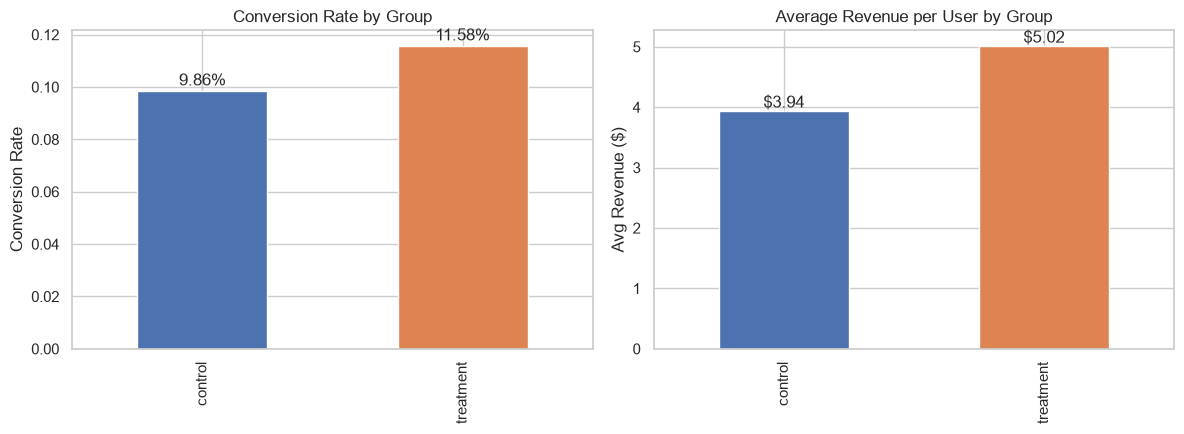

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

summary['conversion_rate'].plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Conversion Rate by Group')
axes[0].set_ylabel('Conversion Rate')
axes[0].set_xlabel('')
for i, v in enumerate(summary['conversion_rate']):
    axes[0].text(i, v + 0.002, f"{v:.2%}", ha='center')

summary['avg_revenue_per_user'].plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'])
axes[1].set_title('Average Revenue per User by Group')
axes[1].set_ylabel('Avg Revenue ($)')
axes[1].set_xlabel('')
for i, v in enumerate(summary['avg_revenue_per_user']):
    axes[1].text(i, v + 0.05, f"${v:.2f}", ha='center')

plt.tight_layout()
plt.show()


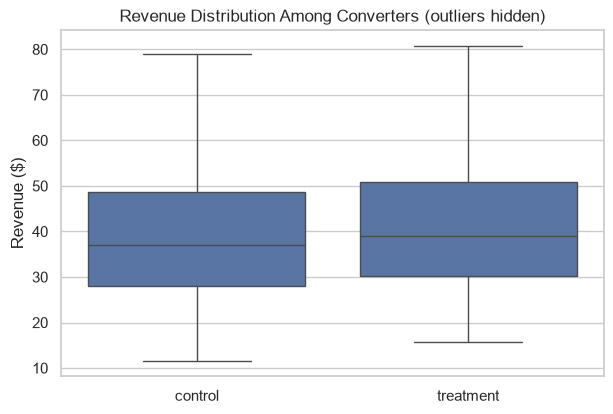

In [ ]:
plt.figure(figsize=(7, 4.5))
sns.boxplot(
    data=df[df['revenue'] > 0], x='group', y='revenue',
    order=['control', 'treatment'], showfliers=False
)
plt.title('Revenue Distribution Among Converters (outliers hidden)')
plt.ylabel('Revenue ($)')
plt.xlabel('')
plt.show()


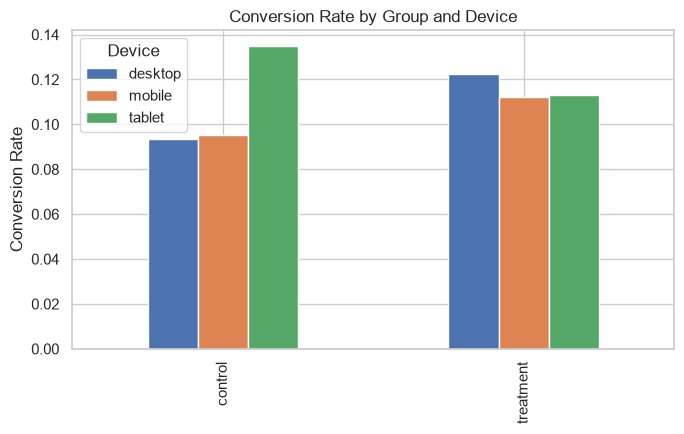

In [ ]:
device_conv = df.groupby(['group', 'device'])['converted'].mean().unstack()
device_conv.plot(kind='bar', figsize=(7, 4.5))
plt.title('Conversion Rate by Group and Device')
plt.ylabel('Conversion Rate')
plt.xlabel('')
plt.legend(title='Device')
plt.tight_layout()
plt.show()


## 4. Power Analysis

Before trusting the significance test, we check whether the experiment was
adequately powered to detect a meaningful effect, and what the smallest
detectable effect actually was given the sample sizes collected.


In [ ]:
baseline_rate = summary.loc['control', 'conversion_rate']
treatment_rate = summary.loc['treatment', 'conversion_rate']
n_control = int(summary.loc['control', 'n'])
n_treatment = int(summary.loc['treatment', 'n'])

# How large would each group need to be to reliably detect a 2-point lift?
required_n = required_sample_size_proportions(
    baseline_rate=baseline_rate,
    minimum_detectable_effect=0.02,
    alpha=0.05,
    power=0.8,
)
print(f"Required sample size per group (2pt lift, 80% power): {required_n}")
print(f"Actual sample sizes -> control: {n_control}, treatment: {n_treatment}")


Required sample size per group (2pt lift, 80% power): 3792
Actual sample sizes -> control: 5000, treatment: 5000


In [ ]:
# Power actually achieved for the observed effect size
achieved = achieved_power_proportions(
    baseline_rate=baseline_rate,
    observed_rate=treatment_rate,
    n_control=n_control,
    n_treatment=n_treatment,
)
print(f"Achieved statistical power for the observed lift: {achieved:.2%}")

# Smallest lift we *could* have reliably detected with our actual sample size
mde = minimum_detectable_effect(baseline_rate=baseline_rate, n_per_group=n_control)
print(f"Minimum detectable effect (80% power, alpha=0.05): {mde:.2%} absolute lift")


Achieved statistical power for the observed lift: 79.45%
Minimum detectable effect (80% power, alpha=0.05): 1.73% absolute lift


## 5. Statistical Significance Testing — Conversion Rate

In [ ]:
conversions = (int(summary.loc['control', 'conversions']), int(summary.loc['treatment', 'conversions']))
n_obs = (n_control, n_treatment)

z_result = two_proportion_z_test(conversions, n_obs)
print(z_result)
print()
for k, v in z_result.details.items():
    print(f"  {k}: {v}")


Two-proportion z-test: statistic=-2.7799, p-value=0.005438 (SIGNIFICANT at alpha=0.05)

  rate_control: 0.0986
  rate_treatment: 0.1158
  absolute_lift: 0.017200000000000007
  relative_lift_pct: 17.444219066937126


In [ ]:
ci_low, ci_high = confidence_interval_proportion_diff(conversions, n_obs, confidence=0.95)
print(f"95% CI for the absolute lift (treatment - control): [{ci_low:.4f}, {ci_high:.4f}]")


95% CI for the absolute lift (treatment - control): [0.0051, 0.0293]


In [ ]:
contingency = pd.crosstab(df['group'], df['converted'])
contingency


converted,0,1
group,,
control,4507,493
treatment,4421,579


In [ ]:
chi_result = chi_square_test(contingency)
print(chi_result)


Chi-square test of independence: statistic=7.5490, p-value=0.006004 (SIGNIFICANT at alpha=0.05)


## 6. Statistical Significance Testing — Revenue

Revenue per user is zero-inflated (most users don't convert) and skewed,
so alongside Welch's t-test we also run the non-parametric
Mann-Whitney U test as a robustness check.


In [ ]:
revenue_control = df.loc[df['group'] == 'control', 'revenue']
revenue_treatment = df.loc[df['group'] == 'treatment', 'revenue']

t_result = welch_t_test(revenue_control, revenue_treatment)
print(t_result)
for k, v in t_result.details.items():
    print(f"  {k}: {v}")


Welch's t-test: statistic=-3.7767, p-value=0.0001598 (SIGNIFICANT at alpha=0.05)
  mean_a: 3.9438199999999997
  mean_b: 5.018946
  std_a: 13.011746886525568
  std_b: 15.358354768702416
  n_a: 5000
  n_b: 5000


In [ ]:
mw_result = mann_whitney_u_test(revenue_control, revenue_treatment)
print(mw_result)
for k, v in mw_result.details.items():
    print(f"  {k}: {v}")


Mann-Whitney U test: statistic=12272478.0000, p-value=0.003332 (SIGNIFICANT at alpha=0.05)
  median_a: 0.0
  median_b: 0.0
  n_a: 5000
  n_b: 5000


## 7. Conclusions & Recommendation

In [ ]:
print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Control conversion rate:    {baseline_rate:.2%} (n={n_control})")
print(f"Treatment conversion rate:  {treatment_rate:.2%} (n={n_treatment})")
print(f"Absolute lift:              {treatment_rate - baseline_rate:.2%}")
print(f"Relative lift:              {(treatment_rate - baseline_rate) / baseline_rate:.1%}")
print(f"Two-proportion z-test p-value: {z_result.p_value:.4g}")
print(f"Achieved power:             {achieved:.1%}")
print(f"Revenue t-test p-value:     {t_result.p_value:.4g}")
print(f"Revenue Mann-Whitney p-value: {mw_result.p_value:.4g}")
print("=" * 60)

if z_result.significant and t_result.significant:
    print("Recommendation: Roll out the treatment (new email design). "
          "Both conversion-rate and revenue improvements are statistically "
          "significant at alpha=0.05.")
elif z_result.significant:
    print("Recommendation: The treatment significantly improves conversion "
          "rate. Revenue difference is not statistically significant, "
          "so consider monitoring revenue post-launch.")
else:
    print("Recommendation: Insufficient evidence that the treatment "
          "outperforms control. Consider extending the test or "
          "redesigning the treatment.")


SUMMARY
Control conversion rate:    9.86% (n=5000)
Treatment conversion rate:  11.58% (n=5000)
Absolute lift:              1.72%
Relative lift:              17.4%
Two-proportion z-test p-value: 0.005438
Achieved power:             79.4%
Revenue t-test p-value:     0.0001598
Revenue Mann-Whitney p-value: 0.003332
Recommendation: Roll out the treatment (new email design). Both conversion-rate and revenue improvements are statistically significant at alpha=0.05.


### Notes & Caveats

- This is a simulated dataset generated for demonstration purposes (see
  `../data/raw_experiment_data.csv` and the generator used to create it).
- The two-proportion z-test and chi-square test are mathematically
  equivalent for a 2x2 table and should agree (as seen above).
- Always pre-register your significance threshold and minimum sample size
  (via a power analysis) *before* running an experiment, not after — testing
  repeatedly ("peeking") without correction inflates the false-positive rate.
